# 03 — Segments and embeddings

**Input:** `artefacts/transcripts.parquet` (from notebook 02).

**Outputs:**
- `artefacts/segments.parquet` with `(segment_id, course_id, lecture_id, text, t_start, t_end, embedding)`.
- `artefacts/figures/segments_tsne.png` and `artefacts/figures/segments_dendrogram.png`.

Segmentation: 1000-character windows with 200-character overlap. Embedding model: `text-embedding-3-small` (1536-dim).

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from tqdm.auto import tqdm

load_dotenv()
OUT = Path('artefacts')
FIG = OUT / 'figures'; FIG.mkdir(exist_ok=True, parents=True)

WINDOW_CHARS  = 1000
OVERLAP_CHARS = 200
EMB_MODEL     = 'text-embedding-3-small'
EMB_BATCH     = 64

client = OpenAI()

## Re-segment imported transcripts into 1000-char windows

Imported transcripts come as ~3–15s segment rows. We concatenate per lecture, then slide a 1000-char window with 200-char overlap. Each window keeps the t_start of the first source-segment it overlaps and the t_end of the last.

In [2]:
transcripts = pd.read_parquet(OUT / 'transcripts.parquet').sort_values(['course_id','lecture_id','segment_idx'])

def window_lecture(course_id, lecture_id, group):
    parts  = group.text.fillna('').astype(str).tolist()
    starts = group.t_start.tolist()
    ends   = group.t_end.tolist()
    joined = ''
    boundaries = []
    for txt, ts, te in zip(parts, starts, ends):
        boundaries.append((len(joined), ts, te))
        joined += txt + ' '
    boundaries.append((len(joined), starts[-1], ends[-1]))

    def time_at(char_pos):
        for i in range(len(boundaries) - 1):
            if boundaries[i][0] <= char_pos < boundaries[i+1][0]:
                return boundaries[i][1], boundaries[i][2]
        return boundaries[-1][1], boundaries[-1][2]

    rows = []
    pos = 0
    while pos < len(joined):
        end = min(pos + WINDOW_CHARS, len(joined))
        text = joined[pos:end].strip()
        if text:
            t_start, _ = time_at(pos)
            _, t_end   = time_at(end - 1)
            rows.append({
                'course_id':  course_id,
                'lecture_id': lecture_id,
                't_start':    t_start,
                't_end':      t_end,
                'text':       text,
            })
        if end == len(joined):
            break
        pos = end - OVERLAP_CHARS
    return rows

all_rows = []
for (cid, lid), grp in transcripts.groupby(['course_id','lecture_id'], sort=False):
    all_rows.extend(window_lecture(cid, lid, grp))

segments = pd.DataFrame(all_rows)
segments['segment_idx'] = segments.groupby(['course_id','lecture_id']).cumcount()
segments['segment_id']  = (
    'c' + segments.course_id.astype(str)
    + '_' + segments.lecture_id
    + '_s' + segments.segment_idx.astype(str).str.zfill(3)
)
print(f'segments: {len(segments):,} across {segments.groupby(["course_id","lecture_id"]).ngroups} lectures')
print(f'mean segments per lecture: {len(segments) / segments.groupby(["course_id","lecture_id"]).ngroups:.1f}')
print(f'mean chars per segment: {segments.text.str.len().mean():.0f}')

segments: 906 across 159 lectures
mean segments per lecture: 5.7
mean chars per segment: 938


## Embed segments via text-embedding-3-small

In [3]:
def embed_batches(texts, batch_size=EMB_BATCH):
    out = []
    for i in tqdm(range(0, len(texts), batch_size)):
        chunk = texts[i:i+batch_size]
        resp = client.embeddings.create(model=EMB_MODEL, input=chunk)
        out.extend(d.embedding for d in resp.data)
    return np.array(out, dtype=np.float32)

embeddings = embed_batches(segments.text.tolist())
print(f'embeddings shape: {embeddings.shape}')

segments['embedding'] = list(embeddings)
segments[['segment_id','course_id','lecture_id','segment_idx','t_start','t_end','text','embedding']].to_parquet(
    OUT / 'segments.parquet', index=False)
print(f'wrote {OUT / "segments.parquet"}')

  0%|          | 0/15 [00:00<?, ?it/s]

embeddings shape: (906, 1536)
wrote artefacts/segments.parquet


## Figure 5.1 — t-SNE of segment embeddings

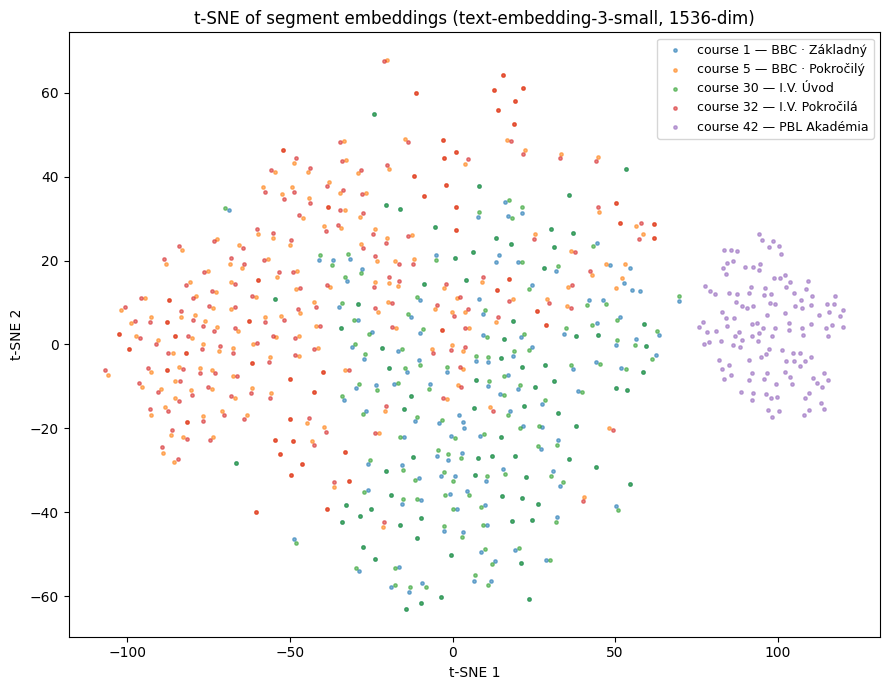

In [4]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

course_names = {1: 'BBC · Základný', 5: 'BBC · Pokročilý',
                30: 'I.V. Úvod', 32: 'I.V. Pokročilá', 42: 'PBL Akadémia'}

tsne = TSNE(n_components=2, perplexity=40, init='pca', random_state=0, max_iter=1000)
xy = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(9, 7))
for cid, label in course_names.items():
    mask = segments.course_id.values == cid
    ax.scatter(xy[mask, 0], xy[mask, 1], s=6, alpha=0.55, label=f'course {cid} — {label}')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE of segment embeddings (text-embedding-3-small, 1536-dim)')
ax.legend(loc='best', fontsize=9)
fig.tight_layout()
fig.savefig(FIG / 'segments_tsne.png', dpi=150)
plt.show()

## Figure 5.2 — Hierarchical dendrogram

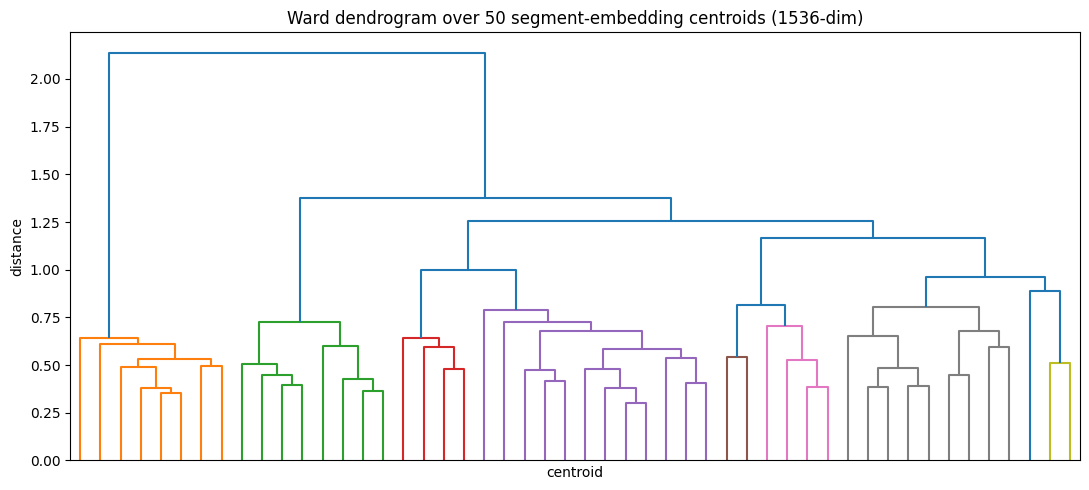

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import MiniBatchKMeans

# Cluster down before linkage to keep the dendrogram readable.
K = 50
km = MiniBatchKMeans(n_clusters=K, random_state=0, n_init=5).fit(embeddings)
centroids = km.cluster_centers_

Z = linkage(centroids, method='ward')
fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=Z[-(K // 6), 2])
ax.set_title(f'Ward dendrogram over {K} segment-embedding centroids (1536-dim)')
ax.set_xlabel('centroid')
ax.set_ylabel('distance')
fig.tight_layout()
fig.savefig(FIG / 'segments_dendrogram.png', dpi=150)
plt.show()